In [1]:
import cv2
import albumentations as A
import matplotlib.pyplot as plt
from pathlib import Path

/home/samay/internship-task/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/samay/internship-task/.venv/lib/python3.12/site-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info The read operation timed out
  data = fetch_version_info()


(434, 620, 3)


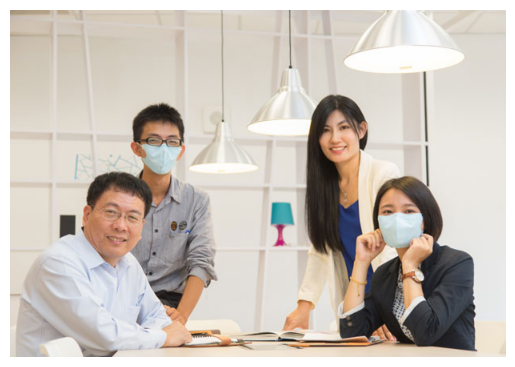

In [2]:
dataset = Path("datasets/face_mask/archive/dataset/images/train")

image_path = next(dataset.glob("*.jpg"))

image = cv2.imread(str(image_path))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print(image.shape)

plt.imshow(image)
plt.axis("off")
plt.show()

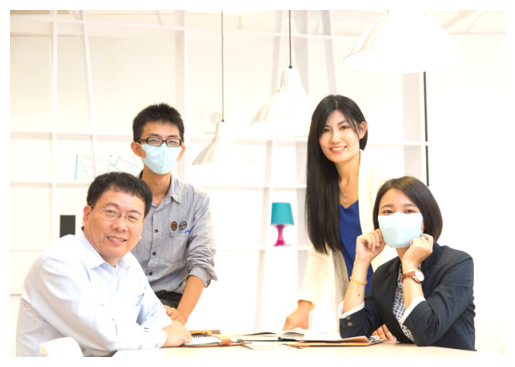

In [6]:
transform = A.Compose([
    A.RandomBrightnessContrast(p=1.0)
])

augmented = transform(image=image)

plt.imshow(augmented["image"])
plt.axis("off")
plt.show()

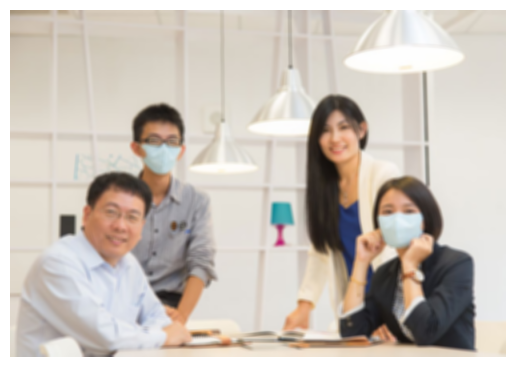

In [7]:
transform = A.Compose([
    A.Blur(blur_limit=5, p=1.0)
])

augmented = transform(image=image)

plt.imshow(augmented["image"])
plt.axis("off")
plt.show()

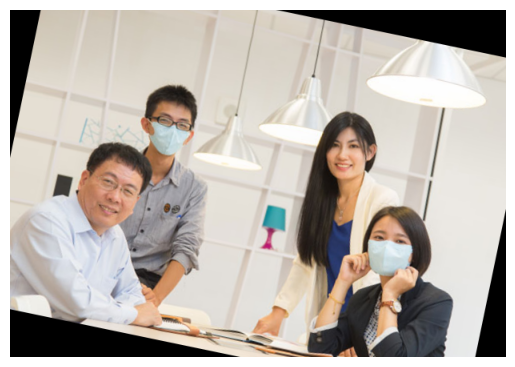

In [10]:
transform = A.Compose([
    A.Rotate(limit=30, p=1.0)
])

augmented = transform(image=image)

plt.imshow(augmented["image"])
plt.axis("off")
plt.show()

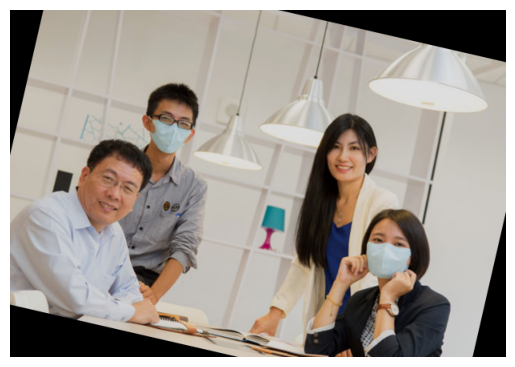

In [11]:
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.Blur(blur_limit=3, p=0.3),
    A.Rotate(limit=20, p=0.5)
])

augmented = transform(image=image)

plt.imshow(augmented["image"])
plt.axis("off")
plt.show()

In [12]:
label_path = image_path.with_suffix(".txt")

bboxes = []

with open(label_path) as f:
    for line in f:
        cls, x, y, w, h = map(float, line.split())
        bboxes.append([x, y, w, h, int(cls)])

print(bboxes)

[[0.3, 0.41013824884792627, 0.0935483870967742, 0.1382488479262673, 1], [0.21451612903225806, 0.6255760368663594, 0.11612903225806452, 0.1774193548387097, 0], [0.6637096774193548, 0.37442396313364057, 0.07903225806451612, 0.12672811059907835, 0], [0.7862903225806451, 0.6175115207373272, 0.09838709677419355, 0.14746543778801843, 1]]


In [13]:
transform = A.Compose(
    [
        A.HorizontalFlip(p=1.0)
    ],
    bbox_params=A.BboxParams(
        format="yolo",
        label_fields=["class_labels"]
    )
)

boxes = [b[:4] for b in bboxes]
labels = [b[4] for b in bboxes]

augmented = transform(
    image=image,
    bboxes=boxes,
    class_labels=labels
)

print(augmented["bboxes"])
print(augmented["class_labels"])

[[0.699999988079071, 0.41013824939727783, 0.09354841709136963, 0.13824886083602905], [0.7854838967323303, 0.6255760192871094, 0.11612904071807861, 0.17741930484771729], [0.33629029989242554, 0.37442395091056824, 0.079032301902771, 0.1267281174659729], [0.21370965242385864, 0.617511510848999, 0.09838712215423584, 0.14746546745300293]]
[1.0, 0.0, 0.0, 1.0]


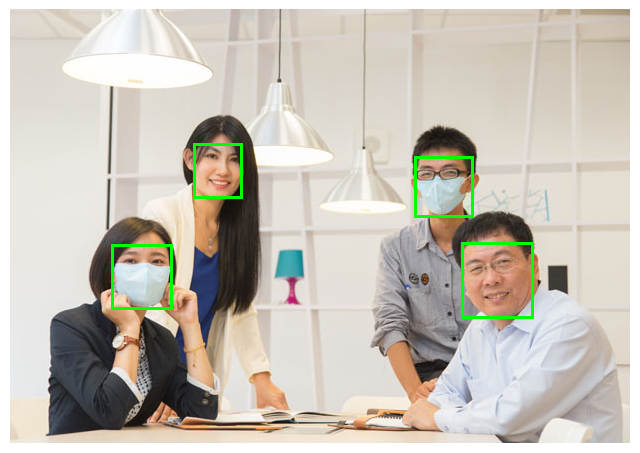

In [14]:
from PIL import Image, ImageDraw

img = Image.fromarray(augmented["image"])
draw = ImageDraw.Draw(img)

w, h = img.size

for box, cls in zip(augmented["bboxes"], augmented["class_labels"]):
    x, y, bw, bh = box

    x1 = (x - bw/2) * w
    y1 = (y - bh/2) * h
    x2 = (x + bw/2) * w
    y2 = (y + bh/2) * h

    draw.rectangle([x1, y1, x2, y2], outline="lime", width=3)

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.show()